# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 그래프에 한글이 깨지거나(경고: Glyph ... missing from font(s) DejaVu Sans) 안 보이는 문제 방지
# Windows 기본 한글 폰트인 '맑은 고딕(Malgun Gothic)'으로 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지

---

## 1) 분류 문제

In [11]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [12]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [13]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1})

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_20288\2999565116.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_cls = Y_cls.replace({"No": 0, "Yes": 1})


In [14]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [15]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

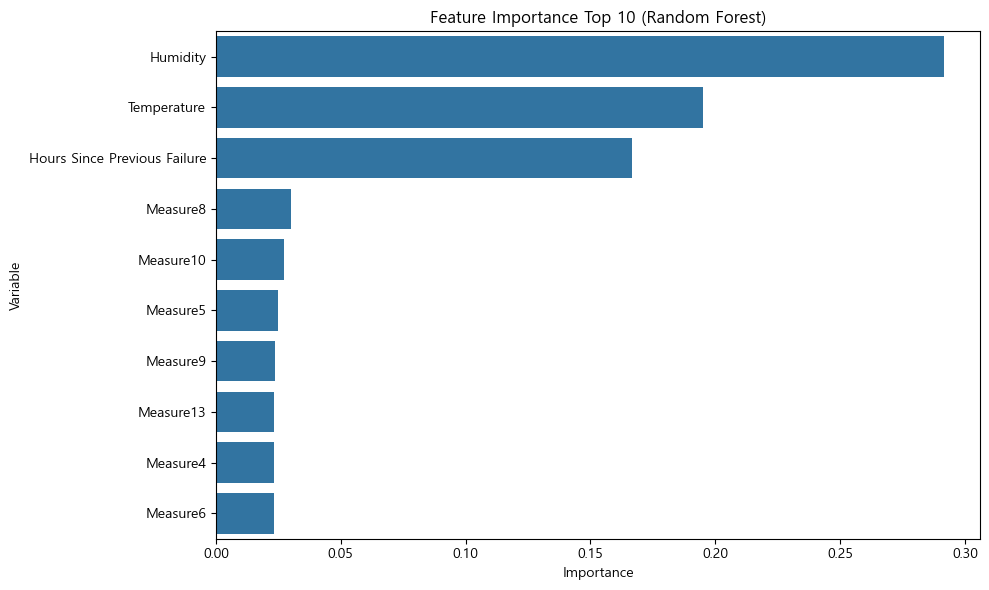

In [16]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [17]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

최적 파라미터: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
최적 F1-score: 0.8058


In [18]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


---

## 2) 회귀 문제

In [19]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [20]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [21]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 26.638
RMSE      : 5.161
MAE       : 3.579
R-squared : 0.896


### 2-2) 변수 중요도 시각화

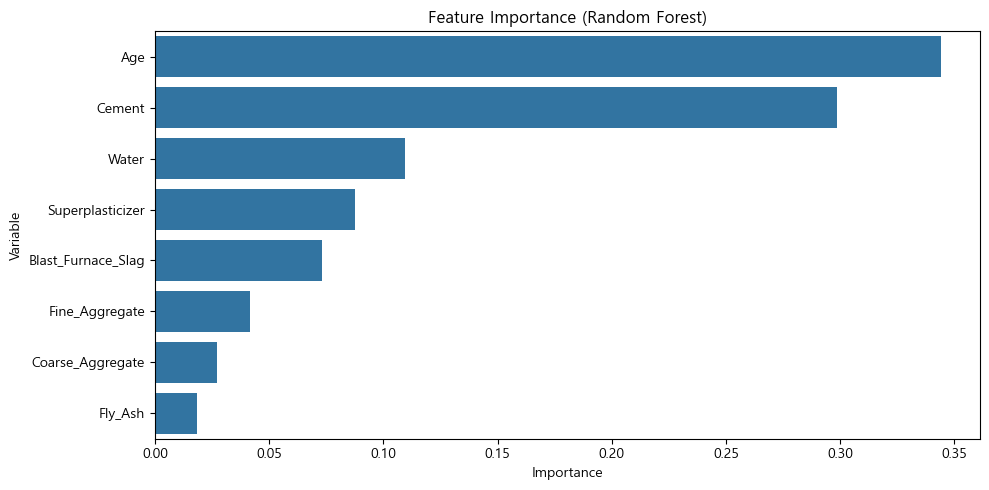

In [22]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

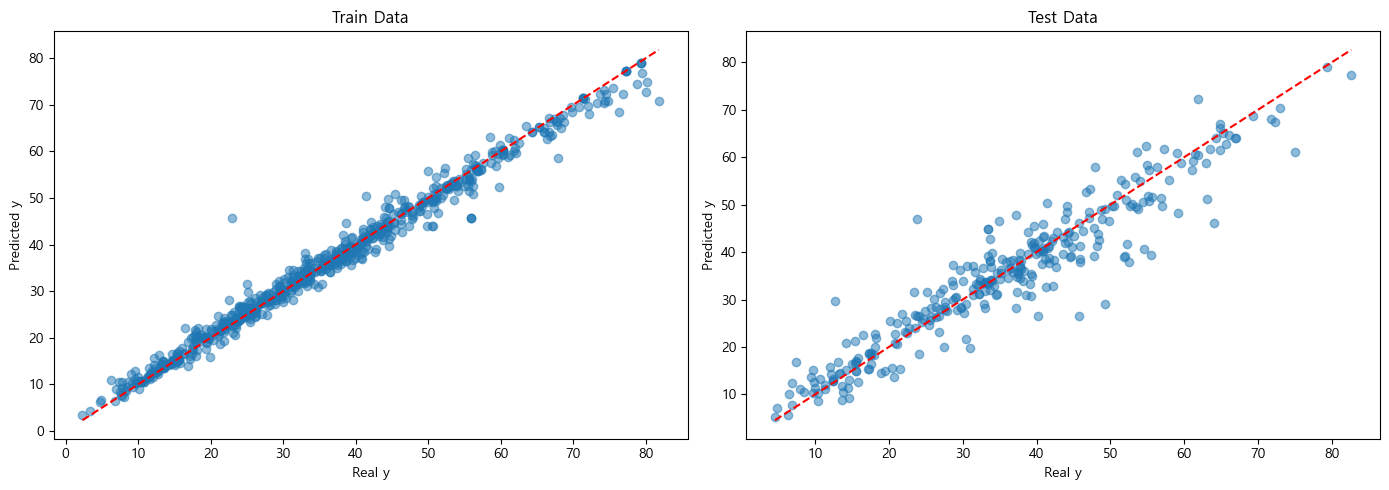

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [24]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
최적 R-squared: 0.8902


In [25]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

MSE       : 28.243
RMSE      : 5.314
MAE       : 3.787
R-squared : 0.890


---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

[프롬프트]

회귀 데이터셋과 분류 데이터셋에 대해

In [34]:
# 변수 중요도 기준 상위 10개 변수 추출
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
top10_vars = var_imp.sort_values(by="Importance", ascending=False).head(10)["Variable"].tolist()
print("상위 10개 변수:", top10_vars)

# 상위 10개 변수만으로 데이터 구성
X_train_top10 = X_train_cls[top10_vars]
X_test_top10 = X_test_cls[top10_vars]

# 전체 변수 모델 (동일 조건 비교를 위해 random_state 고정)
RF_cls_full = RandomForestClassifier(random_state=0)
RF_cls_full.fit(X_train_cls, Y_train_cls)
pred_full = RF_cls_full.predict(X_test_cls)

# 상위 10개 변수 모델
RF_cls_top10 = RandomForestClassifier(random_state=0)
RF_cls_top10.fit(X_train_top10, Y_train_cls)
pred_top10 = RF_cls_top10.predict(X_test_top10)

print("=" * 40)
print("[전체 변수 사용] 변수 수:", X_train_cls.shape[1])
print("=" * 40)
get_classscore(Y_test_cls, pred_full)

print()
print("=" * 40)
print("[상위 10개 변수만 사용]")
print("=" * 40)
get_classscore(Y_test_cls, pred_top10)

상위 10개 변수: ['Humidity', 'Temperature', 'Hours Since Previous Failure', 'Measure8', 'Measure10', 'Measure5', 'Measure9', 'Measure13', 'Measure4', 'Measure6']
[전체 변수 사용] 변수 수: 31
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]

[상위 10개 변수만 사용]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


In [33]:
# 변수 중요도 기준 threshold(0.05) 이상인 변수만 추출
threshold = 0.05
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

selected_vars = var_imp_reg[var_imp_reg["Importance"] >= threshold]["Variable"].tolist()
print("전체 변수 중요도:")
print(var_imp_reg.to_string(index=False))
print()
print("선택된 변수 (중요도 >= %.2f): %d개" % (threshold, len(selected_vars)))
print(selected_vars)

X_train_reg_sel = X_train_reg[selected_vars]
X_test_reg_sel = X_test_reg[selected_vars]

# 전체 변수 모델
RF_reg_full = RandomForestRegressor(random_state=0)
RF_reg_full.fit(X_train_reg, Y_train_reg)
pred_reg_full = RF_reg_full.predict(X_test_reg)

# threshold 기준 선택 변수 모델
RF_reg_sel = RandomForestRegressor(random_state=0)
RF_reg_sel.fit(X_train_reg_sel, Y_train_reg)
pred_reg_sel = RF_reg_sel.predict(X_test_reg_sel)

print()
print("=" * 40)
print("[전체 변수 사용] 변수 수:", X_train_reg.shape[1])
print("=" * 40)
get_regscore(Y_test_reg, pred_reg_full)

print()
print("=" * 40)
print("[중요도 %.2f 이상 변수만 사용] 변수 수: %d" % (threshold, len(selected_vars)))
print("=" * 40)
get_regscore(Y_test_reg, pred_reg_sel)

전체 변수 중요도:
          Variable  Importance
               Age    0.343977
            Cement    0.298375
             Water    0.109431
  Superplasticizer    0.087664
Blast_Furnace_Slag    0.073355
    Fine_Aggregate    0.041648
  Coarse_Aggregate    0.027032
           Fly_Ash    0.018518

선택된 변수 (중요도 >= 0.05): 5개
['Age', 'Cement', 'Water', 'Superplasticizer', 'Blast_Furnace_Slag']

[전체 변수 사용] 변수 수: 8
MSE       : 26.678
RMSE      : 5.165
MAE       : 3.583
R-squared : 0.896

[중요도 0.05 이상 변수만 사용] 변수 수: 5
MSE       : 25.622
RMSE      : 5.062
MAE       : 3.617
R-squared : 0.900


**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

[프롬프트]
RandmoForest가 다양한 의사결정나무를 가지고 학습하다보니 단일 트리보다 유리한지가 궁금해
1. 회귀 데이터셋으로 RandomForest 모델 학습한거랑 단일 의사결정나무 학습한거 비교하는 코드랑
2. 분류 데이터셋으로 RandomForest 모델 학습한거랑 단일 의사결정나무 학습한거 비교하는 코드랑

In [28]:
from sklearn.tree import DecisionTreeClassifier

# 단일 의사결정나무 학습
DT_cls = DecisionTreeClassifier(random_state=0)
DT_cls.fit(X_train_cls, Y_train_cls)
DT_cls_pred = DT_cls.predict(X_test_cls)

# Random Forest (공정한 비교를 위해 random_state 고정 후 재학습)
RF_cls_cmp = RandomForestClassifier(random_state=0)
RF_cls_cmp.fit(X_train_cls, Y_train_cls)
RF_cls_cmp_pred = RF_cls_cmp.predict(X_test_cls)

print("=" * 40)
print("[단일 의사결정나무 - 테스트 성능]")
print("=" * 40)
get_classscore(Y_test_cls, DT_cls_pred)

print()
print("=" * 40)
print("[Random Forest - 테스트 성능]")
print("=" * 40)
get_classscore(Y_test_cls, RF_cls_cmp_pred)

# 과적합 확인: 학습 데이터 성능과 테스트 데이터 성능 차이 비교
print()
print("과적합 비교 (학습 vs 테스트 F1-score)")
print("의사결정나무  : 학습 %.3f / 테스트 %.3f" % (
    f1_score(Y_train_cls, DT_cls.predict(X_train_cls)),
    f1_score(Y_test_cls, DT_cls_pred)))
print("Random Forest : 학습 %.3f / 테스트 %.3f" % (
    f1_score(Y_train_cls, RF_cls_cmp.predict(X_train_cls)),
    f1_score(Y_test_cls, RF_cls_cmp_pred)))

[단일 의사결정나무 - 테스트 성능]
Accuracy  : 0.994
Precision : 0.667
Recall    : 0.727
F1-score  : 0.696

혼동행렬
[[2340    8]
 [   6   16]]

[Random Forest - 테스트 성능]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]

과적합 비교 (학습 vs 테스트 F1-score)
의사결정나무  : 학습 1.000 / 테스트 0.696
Random Forest : 학습 1.000 / 테스트 0.811


In [29]:
from sklearn.tree import DecisionTreeRegressor

# 단일 의사결정나무 학습
DT_reg = DecisionTreeRegressor(random_state=0)
DT_reg.fit(X_train_reg, Y_train_reg)
DT_reg_pred = DT_reg.predict(X_test_reg)

# Random Forest
RF_reg_cmp = RandomForestRegressor(random_state=0)
RF_reg_cmp.fit(X_train_reg, Y_train_reg)
RF_reg_cmp_pred = RF_reg_cmp.predict(X_test_reg)

print("=" * 40)
print("[단일 의사결정나무 - 테스트 성능]")
print("=" * 40)
get_regscore(Y_test_reg, DT_reg_pred)

print()
print("=" * 40)
print("[Random Forest - 테스트 성능]")
print("=" * 40)
get_regscore(Y_test_reg, RF_reg_cmp_pred)

# 과적합 확인 (학습 vs 테스트 R-squared)
print()
print("과적합 비교 (학습 vs 테스트 R-squared)")
print("의사결정나무  : 학습 %.3f / 테스트 %.3f" % (
    r2_score(Y_train_reg, DT_reg.predict(X_train_reg)),
    r2_score(Y_test_reg, DT_reg_pred)))
print("Random Forest : 학습 %.3f / 테스트 %.3f" % (
    r2_score(Y_train_reg, RF_reg_cmp.predict(X_train_reg)),
    r2_score(Y_test_reg, RF_reg_cmp_pred)))

[단일 의사결정나무 - 테스트 성능]
MSE       : 58.132
RMSE      : 7.624
MAE       : 4.860
R-squared : 0.774

[Random Forest - 테스트 성능]
MSE       : 26.678
RMSE      : 5.165
MAE       : 3.583
R-squared : 0.896

과적합 비교 (학습 vs 테스트 R-squared)
의사결정나무  : 학습 0.996 / 테스트 0.774
Random Forest : 학습 0.983 / 테스트 0.896


**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

[프롬 프트]

Random Forest에 하이퍼파라미터가 엄청 많아.
1. 주요 하이퍼 파라미터

In [35]:
params_cls = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 15, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_cls_tune = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params_cls,
    cv=5,
    scoring="f1",      # 불균형 데이터이므로 F1 기준
    n_jobs=-1,
    verbose=1
)
grid_cls_tune.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls_tune.best_params_)
print("교차검증 최고 F1-score: %.4f" % grid_cls_tune.best_score_)

# 상위 5개 조합 확인 (왜 이 조합이 선택됐는지 해석용)
cv_result = pd.DataFrame(grid_cls_tune.cv_results_)
cols = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
print(cv_result[cols].sort_values("rank_test_score").head(5))

# 최적 모델의 테스트 성능 (기본 모델과 비교)
print()
print("[기본 모델 테스트 성능]")
base_cls = RandomForestClassifier(random_state=0).fit(X_train_cls, Y_train_cls)
get_classscore(Y_test_cls, base_cls.predict(X_test_cls))

print()
print("[튜닝 모델 테스트 성능]")
get_classscore(Y_test_cls, grid_cls_tune.predict(X_test_cls))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


KeyboardInterrupt: 

In [ ]:
params_reg = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 15, None],
    "max_features": [3, "sqrt", None],   # 3 = 전체 8개 변수의 약 1/3
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_reg_tune = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_reg_tune.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg_tune.best_params_)
print("교차검증 최고 R-squared: %.4f" % grid_reg_tune.best_score_)

cv_result_reg = pd.DataFrame(grid_reg_tune.cv_results_)
cols = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
print(cv_result_reg[cols].sort_values("rank_test_score").head(5))

print()
print("[기본 모델 테스트 성능]")
base_reg = RandomForestRegressor(random_state=0).fit(X_train_reg, Y_train_reg)
get_regscore(Y_test_reg, base_reg.predict(X_test_reg))

print()
print("[튜닝 모델 테스트 성능]")
get_regscore(Y_test_reg, grid_reg_tune.predict(X_test_reg))

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.